In [1]:
import warnings
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

from catboost import CatBoostClassifier, Pool
import lightgbm as lgb

warnings.filterwarnings("ignore")

# ── Constants ─────────────────────────────────────────────────────────────────
DATA_PATH    = "train_df.csv"
TARGET_COL   = "gb"
ID_COL       = "id"
RANDOM_STATE = 42
N_SPLITS     = 5

# Color palette for plots
PALETTE = {
    "primary":   "#2E86AB",
    "secondary": "#A23B72",
    "accent":    "#F18F01",
    "pos":       "#C73E1D",
    "neg":       "#3A7D44",
}

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette([PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"]])
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 13, "axes.labelsize": 11})
%matplotlib inline

np.random.seed(RANDOM_STATE)
print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
df = pd.read_csv('train_df.csv', sep='\t')

Creating a list of "usuble" columns for train, we can explore it, and with this columns  our model actually learns.

In [3]:
num_cols = sorted(c for c in df.columns if c.startswith("num_"))
cat_cols = sorted(c for c in df.columns if c.startswith("cat_"))
feature_cols = num_cols + cat_cols

In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Number of uniqe ID's: {df['id'].nunique()}")

Rows: 26824, Columns: 554
Number of uniqe ID's: 5243


As we see here, users make many things in our dataset, so, to prevent data leakeage in future, we change we method, how we sliit aour dataset for train/test parts

In [ ]:
target_counts = df['gb'].value_counts().sort_index()
pos_rate = df['gb'].mean()
imbalance_ratio = target_counts[0] / target_counts[1]

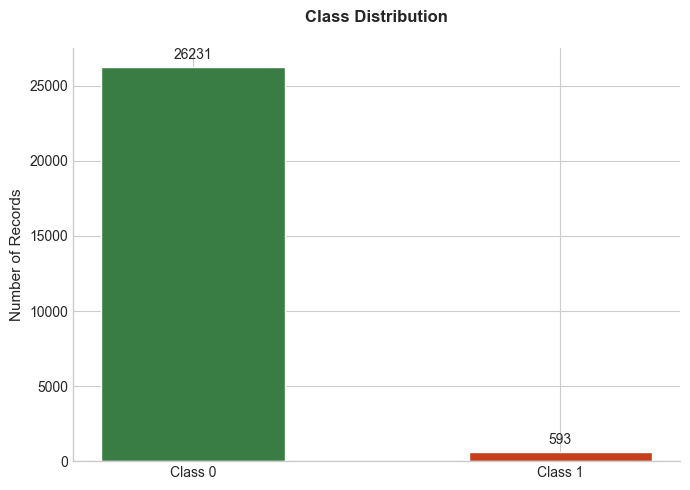

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Class 0", "Class 1"],
    target_counts.values,
    color=[PALETTE["neg"], PALETTE["pos"]],
    edgecolor="white", 
    width=0.5
)

ax.bar_label(bars, padding=4, fmt="%d")

ax.set_title(
    f"Class Distribution\n",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel("Number of Records", fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

We need to find out, what key matrices we will using to understand, if our model perform well. We have class imbalance, chus pression, recall, Roc-auc and f1 will be in this list

In [7]:
missing_pct = df[feature_cols].isnull().mean() * 100
empty_cols = missing_pct[missing_pct >= 100].index.tolist()

print(f"Number of emtry columns: {len(empty_cols)}")

Number of emtry columns: 12


This columns not given us any usefull information, but takes power from our systen, chus the best desicion in to delete it.

Median skewness: 10.00
Features with |skewness| > 5: 258
Features with |skewness| > 10: 202


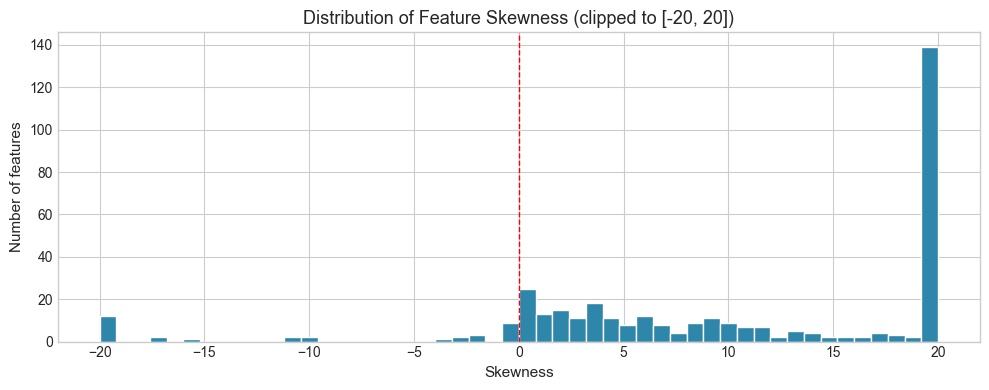

In [8]:
# Skewness and outlier analysis
valid_num_cols = [c for c in num_cols if df[c].notna().any() and df[c].notna().sum() > 100]

skew_series = df[valid_num_cols].skew().sort_values(ascending=False)
print(f"Median skewness: {skew_series.median():.2f}")
print(f"Features with |skewness| > 5: {(skew_series.abs() > 5).sum()}")
print(f"Features with |skewness| > 10: {(skew_series.abs() > 10).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(skew_series.clip(-20, 20), bins=50, color=PALETTE["primary"], edgecolor="white")
ax.set_xlabel("Skewness")
ax.set_ylabel("Number of features")
ax.set_title("Distribution of Feature Skewness (clipped to [-20, 20])")
ax.axvline(0, color="red", ls="--", lw=1)
plt.tight_layout()
plt.show()

This graph is a histogram of feature skewness.
Skewness measures how asymmetrical your data distribution is. A perfectly symmetrical bell curve has a skewness of 0. Our dataset is packed with features that have massive, long tails or extreme outliers. 
SO, when weare using Tree-Based Models, we dont need to scale skewness, becouse the way they works. They make decision by splitting data based on threshplds, and after that minimizing entropy. But, for the logistic regression we use miplitlies weghts by feature values, so, after seeing so much out liear we need to use skeiler. Anf we choose Robust scaler.  it users median and IQR, so, huge number and median does break in those cases.

In [10]:
# Mann-Whitney U test: which numerical features differ significantly between classes?
mw_results = []
valid_num_cols = [c for c in num_cols if df[c].notna().any() and df[c].notna().sum() > 100]

for col in valid_num_cols:
    vals_0 = df.loc[df[TARGET_COL] == 0, col].dropna()
    vals_1 = df.loc[df[TARGET_COL] == 1, col].dropna()
    if len(vals_0) < 10 or len(vals_1) < 10:
        continue
    stat, pval = mannwhitneyu(vals_0, vals_1, alternative="two-sided")
    mw_results.append({"column": col, "p_value": pval, "median_gb0": vals_0.median(), "median_gb1": vals_1.median()})

mw_df = pd.DataFrame(mw_results).sort_values("p_value")
significant = mw_df[mw_df["p_value"] < 0.05]
print(f"Numerical features significantly different between classes (p<0.05): {len(significant)} / {len(mw_df)}")
display(significant.head(15))

Numerical features significantly different between classes (p<0.05): 235 / 309


,column,p_value,median_gb0,median_gb1
5,num_105,4.972279e-82,-12423.760,-95489.150
79,num_197,4.514105e-79,13.000,6.000
263,num_43,1.134797e-74,330000.000,1295417.480
25,num_132,2.375108e-66,57.000,33.000
194,num_340,4.257951e-66,1721.000,1000.000
27,num_134,4.257951e-66,1717.000,996.000
140,num_276,2.634840e-63,27959.885,126871.460
53,num_169,1.210315e-59,17221.735,77870.775
111,num_234,1.198603e-58,1385.000,633.000
112,num_235,1.672505e-58,46.000,21.000


**Why:** The Mann-Whitney U test is a non-parametric test that checks if the distribution of each numerical feature differs between the two target classes. Features with very low p-values are statistically associated with default — they are the most promising predictors. We use Mann-Whitney (not t-test) because financial data is typically heavily skewed and non-normal.

In [11]:
# Chi-squared test for categorical features vs target
chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COL])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(ct)
    chi2_results.append({"column": col, "chi2": chi2, "p_value": pval, "dof": dof, "cardinality": df[col].nunique()})

chi2_df = pd.DataFrame(chi2_results).sort_values("p_value")
chi2_sig = chi2_df[chi2_df["p_value"] < 0.05]
print(f"Categorical features significantly associated with target (p<0.05): {len(chi2_sig)} / {len(chi2_df)}")
display(chi2_df.head(15))

Categorical features significantly associated with target (p<0.05): 69 / 135


,column,chi2,p_value,dof,cardinality
92,cat_60,6433.486756,0.000000e+00,1312,1313
133,cat_98,3907.659332,3.659045e-222,1460,1461
67,cat_38,1825.682268,8.277044e-172,427,428
100,cat_68,621.776614,9.614437e-136,2,3
11,cat_109,617.136939,3.028121e-132,4,5
46,cat_19,1895.846118,4.448282e-127,629,630
7,cat_105,313.390590,8.873561e-69,2,3
20,cat_117,173.847478,1.776233e-38,2,3
73,cat_43,161.162237,1.009404e-35,2,3
55,cat_27,151.733015,3.327455e-30,6,7


Max cardinality: 1461 (column: cat_98)
Features with cardinality > 20: 8
Features with cardinality <= 5: 119


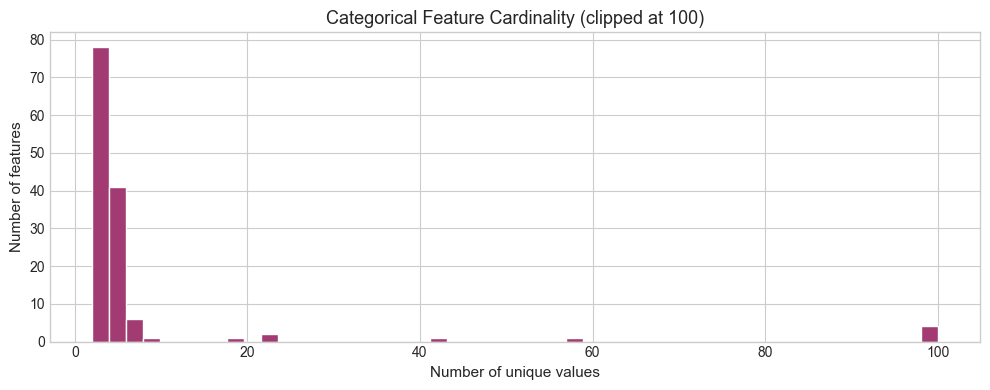

In [ ]:
# Categorical feature cardinality
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print(f"Max cardinality: {cardinality.max()} (column: {cardinality.idxmax()})")
print(f"Features with cardinality > 20: {(cardinality > 20).sum()}")
print(f"Features with cardinality <= 5: {(cardinality <= 5).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cardinality.clip(0, 100), bins=50, color=PALETTE["secondary"], edgecolor="white")
ax.set_xlabel("Number of unique values")
ax.set_ylabel("Number of features")
ax.set_title("Categorical Feature Cardinality (clipped at 100)")
plt.tight_layout()
plt.show()

We need to understand how spleing, so, based on this we will use `StratifiedGroupKFold` (splitting by `id` groups) instead of simple `train_test_split`.

So, beafore working with dataset, and do it, we need to clean it.

In [13]:
cols_before = len(df.columns)
df = df.drop(columns=empty_cols, errors="ignore")
print(f"Dropped {cols_before - len(df.columns)} columns with 100% missing values.")

# Update column lists
cat_cols = sorted([c for c in df.columns if c.startswith("cat_")])
num_cols = sorted([c for c in df.columns if c.startswith("num_")])

# ── Step 2: Drop exact duplicate columns ─────────────────────────────────────
feature_cols = cat_cols + num_cols
dup_groups = df[feature_cols].T.duplicated(keep="first")
dup_cols = dup_groups[dup_groups].index.tolist()
df = df.drop(columns=dup_cols, errors="ignore")
print(f"Dropped {len(dup_cols)} exact duplicate columns.")

cat_cols = sorted([c for c in df.columns if c.startswith("cat_")])
num_cols = sorted([c for c in df.columns if c.startswith("num_")])

FINAL_FEATURES = cat_cols + num_cols

print(f"\n=== Final feature set: {len(cat_cols)} categorical + {len(num_cols)} numerical = {len(FINAL_FEATURES)} total ===")

Dropped 12 columns with 100% missing values.
Dropped 33 exact duplicate columns.

=== Final feature set: 126 categorical + 380 numerical = 506 total ===


In [14]:
# ── Common preprocessing applied to the whole dataset ────────────────────────
# This only includes operations that don't leak information from val into train:
#   - Casting categorical columns to int
#   - Extracting X, y, and groups

# Make sure categoricals are int-typed (they are integer codes already)
for col in cat_cols:
    df[col] = df[col].fillna(-1).astype(int)

X_all = df[FINAL_FEATURES].copy()
y_all = df[TARGET_COL].values
groups_all = df[ID_COL].values

# Identify which final features are MNAR (for LR missing indicators)
final_num = [c for c in FINAL_FEATURES if c.startswith("num_")]
final_cat = [c for c in FINAL_FEATURES if c.startswith("cat_")]

final_num = [c for c in FINAL_FEATURES if c.startswith("num_")]
final_cat = [c for c in FINAL_FEATURES if c.startswith("cat_")]

# ✅ Додай це:
# MNAR = числові колонки з пропусками (для них додамо бінарний індикатор is_missing)
final_mnar = [c for c in final_num if X_all[c].isnull().any()]

print(f"MNAR columns (with missings): {len(final_mnar)}")

print(f"X_all shape: {X_all.shape}")
print(f"Final numerical:   {len(final_num)}")
print(f"Final categorical: {len(final_cat)}")
print(f"Target balance: {pd.Series(y_all).value_counts(normalize=True).round(4).to_dict()}")

MNAR columns (with missings): 319
X_all shape: (26824, 506)
Final numerical:   380
Final categorical: 126
Target balance: {0: 0.9779, 1: 0.0221}


In [15]:
# StratifiedGroupKFold: stratifies by target, groups by entity ID
# This ensures:
#  1. No entity appears in both train and val (prevents leakage)
#  2. Each fold has roughly the same positive class rate

entity_target = df.groupby(ID_COL)[TARGET_COL].first().reset_index()
entity_y = df[ID_COL].map(entity_target.set_index(ID_COL)[TARGET_COL]).values

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(sgkf.split(X_all, entity_y, groups=groups_all))

print(f"CV splits (StratifiedGroupKFold, {N_SPLITS} folds):")
for i, (tr, va) in enumerate(splits):
    n_groups_tr = len(set(groups_all[tr]))
    n_groups_va = len(set(groups_all[va]))
    overlap = set(groups_all[tr]) & set(groups_all[va])
    print(f"  Fold {i}: train={len(tr):,} rows ({n_groups_tr} entities), "
          f"val={len(va):,} rows ({n_groups_va} entities), "
          f"val positive rate={y_all[va].mean():.2%}, "
          f"id overlap={len(overlap)}")

CV splits (StratifiedGroupKFold, 5 folds):
  Fold 0: train=21,510 rows (4195 entities), val=5,314 rows (1048 entities), val positive rate=2.80%, id overlap=0
  Fold 1: train=21,402 rows (4194 entities), val=5,422 rows (1049 entities), val positive rate=1.83%, id overlap=0
  Fold 2: train=21,487 rows (4194 entities), val=5,337 rows (1049 entities), val positive rate=2.59%, id overlap=0
  Fold 3: train=21,429 rows (4195 entities), val=5,395 rows (1048 entities), val positive rate=1.98%, id overlap=0
  Fold 4: train=21,468 rows (4194 entities), val=5,356 rows (1049 entities), val positive rate=1.87%, id overlap=0


In [16]:
# ── Helper: sanitize column names (LightGBM/CatBoost don't like special chars) ──
def sanitize_names(cols):
    """Replace special characters in column names."""
    return [re.sub(r"[^\w]", "_", c) for c in cols]


# ── Helper: label encode categoricals (leakage-safe: fit on train only) ──
def encode_categoricals(X_train, X_val, cat_cols):
    """Label encoding fitted on train, applied to val."""
    X_tr, X_va = X_train.copy(), X_val.copy()
    for col in cat_cols:
        if col not in X_tr.columns:
            continue
        uniques = X_tr[col].astype(str).fillna("__NA__").unique()
        mapping = {v: i for i, v in enumerate(sorted(uniques))}
        X_tr[col] = X_tr[col].astype(str).fillna("__NA__").map(mapping).fillna(-1).astype(int)
        X_va[col] = X_va[col].astype(str).fillna("__NA__").map(mapping).fillna(-1).astype(int)
    return X_tr, X_va


# ── Preprocessing for LOGISTIC REGRESSION ────────────────────────────────────
def prepare_for_logreg(X_train, X_val, mnar_cols, num_cols, cat_cols):
    """
    Full preprocessing pipeline for Logistic Regression:
      1. Add binary is_missing indicators for MNAR columns
      2. Label encode categoricals (fit on train)
      3. Median imputation (fit on train)
      4. RobustScaler (fit on train)
    """
    X_tr = X_train.copy()
    X_va = X_val.copy()
    
    # 1. MNAR indicators
    for col in mnar_cols:
        if col in X_tr.columns:
            X_tr[f"{col}__miss"] = X_tr[col].isnull().astype(np.int8)
            X_va[f"{col}__miss"] = X_va[col].isnull().astype(np.int8)

    # 2. Label encoding
    X_tr, X_va = encode_categoricals(X_tr, X_va, cat_cols)

    # 3. Median imputation (fitted on train)
    # ✅ Виправлена версія:
    medians = X_tr.median()
    medians = medians.fillna(0)   # fallback: якщо вся колонка NaN → заповнюємо 0
    X_tr = X_tr.fillna(medians)
    X_va = X_va.fillna(medians)

    # 4. RobustScaler (fitted on train)
    all_cols = X_tr.columns.tolist()
    scaler = RobustScaler()
    X_tr_s = pd.DataFrame(scaler.fit_transform(X_tr), columns=all_cols, index=X_tr.index)
    X_va_s = pd.DataFrame(scaler.transform(X_va), columns=all_cols, index=X_va.index)

    return X_tr_s, X_va_s


# ── Preprocessing for TREE MODELS (CatBoost, LightGBM) ──────────────────────
def prepare_for_trees(X_train, X_val, cat_cols):
    """
    Minimal preprocessing for tree-based models:
      - Label encode categoricals (fit on train)
      - NaN values are kept as-is (CatBoost/LightGBM handle them natively)
      - No scaling needed (trees are scale-invariant)
    """
    return encode_categoricals(X_train, X_val, cat_cols)


# ── Helper: find optimal F1 threshold ────────────────────────────────────────
def find_optimal_f1(y_true, y_prob, n=200):
    """Search for the probability threshold that maximizes F1-score."""
    thresholds = np.linspace(0.001, 0.999, n)
    best_f1, best_t = 0.0, 0.5
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


print("Preprocessing functions defined.")

Preprocessing functions defined.


In [17]:
# Числові: значущі за Mann-Whitney та наявні в X_all
sig_num = [c for c in significant["column"].tolist() if c in X_all.columns]

# Категоріальні: значущі за Chi-squared та наявні в X_all
sig_cat = [c for c in chi2_sig["column"].tolist() if c in X_all.columns]

# MNAR: тільки серед відібраних числоваих
sig_mnar = [c for c in sig_num if X_all[c].isnull().any()]

print(f"Features for LR:")
print(f"  Numerical  (sig): {len(sig_num)}  (було {len(final_num)})")
print(f"  Categorical(sig): {len(sig_cat)}  (було {len(final_cat)})")
print(f"  MNAR indicators : {len(sig_mnar)}")

# Тепер помилки не буде
sig_features = sig_num + sig_cat
X_all_lr = X_all[sig_features].copy()

Features for LR:
  Numerical  (sig): 217  (було 380)
  Categorical(sig): 69  (було 126)
  MNAR indicators : 166


  Fold 0: PR-AUC=0.0361 | ROC-AUC=0.6060 | F1=0.0548 | Precision=0.0282 | Recall=1.0000 (thr=0.497)
  Fold 1: PR-AUC=0.0300 | ROC-AUC=0.5582 | F1=0.1111 | Precision=0.2593 | Recall=0.0707 (thr=0.538)
  Fold 2: PR-AUC=0.0273 | ROC-AUC=0.5226 | F1=0.0505 | Precision=0.0259 | Recall=1.0000 (thr=0.482)
  Fold 3: PR-AUC=0.0233 | ROC-AUC=0.6095 | F1=0.0401 | Precision=0.0204 | Recall=1.0000 (thr=0.497)
  Fold 4: PR-AUC=0.0477 | ROC-AUC=0.6389 | F1=0.0405 | Precision=0.0625 | Recall=0.0300 (thr=0.503)

Logistic Regression — mean CV:
  pr_auc      : 0.0329 ± 0.0095
  roc_auc     : 0.5870 ± 0.0462
  f1          : 0.0594 ± 0.0296
  precision   : 0.0793 ± 0.1020
  recall      : 0.6201 ± 0.5203


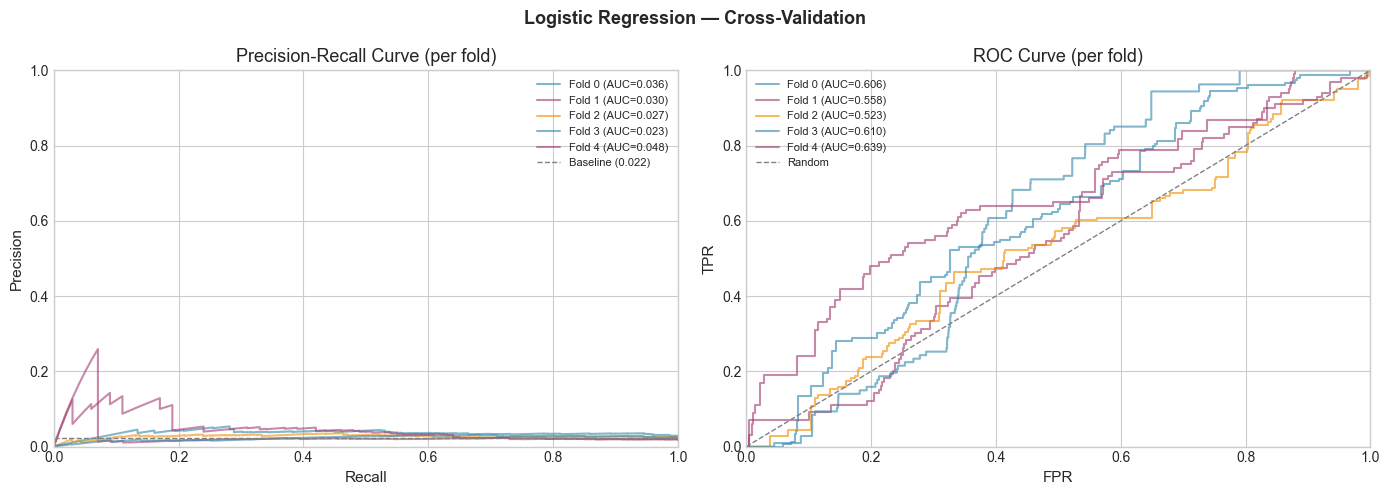

In [18]:
oof_lr = np.full(len(y_all), np.nan)
lr_fold_metrics = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    X_tr_raw = X_all_lr.iloc[train_idx]   # ← змінено
    X_va_raw = X_all_lr.iloc[val_idx] 
    y_tr = y_all[train_idx]
    y_va = y_all[val_idx]

    X_tr_lr, X_va_lr = prepare_for_logreg(
        X_tr_raw, X_va_raw, final_mnar, final_num, final_cat
    )

    lr = LogisticRegression(
        C=0.1, penalty="l2", solver="saga", max_iter=300,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )
    lr.fit(X_tr_lr, y_tr)
    val_prob = lr.predict_proba(X_va_lr)[:, 1]
    oof_lr[val_idx] = val_prob

    # ── Metrics ───────────────────────────────────────────────────────────────
    pr_auc  = average_precision_score(y_va, val_prob)
    roc_auc = roc_auc_score(y_va, val_prob)

    best_t, best_f1 = find_optimal_f1(y_va, val_prob)
    y_pred = (val_prob >= best_t).astype(int)
    precision = precision_score(y_va, y_pred, zero_division=0)
    recall    = recall_score(y_va, y_pred, zero_division=0)

    lr_fold_metrics.append({
        "fold": fold_idx, "pr_auc": pr_auc, "roc_auc": roc_auc,
        "precision": precision, "recall": recall, "f1": best_f1, "threshold": best_t,
    })
    print(
        f"  Fold {fold_idx}: PR-AUC={pr_auc:.4f} | ROC-AUC={roc_auc:.4f} | "
        f"F1={best_f1:.4f} | Precision={precision:.4f} | Recall={recall:.4f} "
        f"(thr={best_t:.3f})"
    )

    # ── PR curve per fold ─────────────────────────────────────────────────────
    prec_c, rec_c, _ = precision_recall_curve(y_va, val_prob)
    fpr, tpr, _      = roc_curve(y_va, val_prob)

    axes[0].plot(rec_c, prec_c, alpha=0.6, label=f"Fold {fold_idx} (AUC={pr_auc:.3f})")
    axes[1].plot(fpr,   tpr,    alpha=0.6, label=f"Fold {fold_idx} (AUC={roc_auc:.3f})")

# ── Summary ───────────────────────────────────────────────────────────────────
lr_metrics_df = pd.DataFrame(lr_fold_metrics)

print(f"\nLogistic Regression — mean CV:")
for col in ["pr_auc", "roc_auc", "f1", "precision", "recall"]:
    print(f"  {col:12s}: {lr_metrics_df[col].mean():.4f} ± {lr_metrics_df[col].std():.4f}")

# ── Finish plots ──────────────────────────────────────────────────────────────
baseline = y_all.mean()

axes[0].axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline ({baseline:.3f})")
axes[0].set_xlabel("Recall");  axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (per fold)")
axes[0].legend(fontsize=8);    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="Random")
axes[1].set_xlabel("FPR");     axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve (per fold)")
axes[1].legend(fontsize=8);    axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle("Logistic Regression — Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
!pip install "optuna-integration[catboost]"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# 1. Спершу створюємо індекси категоріальних фічей
cat_feature_indices = [
    FINAL_FEATURES.index(c) for c in final_cat if c in FINAL_FEATURES
]x

# 2. Створюємо пустий список, куди збережемо готові фолди
precomputed_pools = []

print("⏳ Готуємо та кешуємо CatBoost Pools для всіх фолдів (1 раз)...")

for train_idx, val_idx in splits:
    X_tr_raw, X_va_raw = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_va = y_all[train_idx], y_all[val_idx]
    
    # Виконуємо обробку даних
    X_tr_cb, X_va_cb = prepare_for_trees(X_tr_raw, X_va_raw, final_cat)
    safe_names = sanitize_names(X_tr_cb.columns.tolist())
    X_tr_cb.columns = safe_names
    X_va_cb.columns = safe_names
    
    # Пакуємо в бінарний формат CatBoost
    train_pool = Pool(X_tr_cb, y_tr, cat_features=cat_feature_indices)
    val_pool = Pool(X_va_cb, y_va, cat_features=cat_feature_indices)
    
    # Зберігаємо у список
    precomputed_pools.append((train_pool, val_pool, y_va))

print("✅ Все готово! Дані в пам'яті.")

⏳ Готуємо та кешуємо CatBoost Pools для всіх фолдів (1 раз)...
✅ Все готово! Дані в пам'яті.


In [23]:
import numpy as np
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score

# 1. ── ПЕРЕДОБРОБКА ТА КЕШУВАННЯ ДАНИХ (1 раз перед Optuna) ─────────────────
# Визначаємо індекси нечислових (категоріальних) ознак
cat_feature_indices = [
    FINAL_FEATURES.index(c) for c in final_cat if c in FINAL_FEATURES
]



# 2. ── ФУНКЦІЯ ОПТИМІЗАЦІЇ ДЛЯ OPTUNA ──────────────────────────────────────
def objective(trial):
    params = {
        # ── Загальні параметри дерева та регуляризація ──
        "depth":             trial.suggest_int("depth", 4, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength":   trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 100), # захист від перенавчання міноритарного класу
        
        # ── ПАРАМЕТРИ ДЛЯ НЕЧИСЛОВИХ ДАНИХ ТА ПОЄДНАННЯ ФІЧ ──
        "max_ctr_complexity": trial.suggest_int("max_ctr_complexity", 1, 3), # Скільки фічей поєднувати (1 - без комбінацій, 3 - трійки)
        "one_hot_max_size":   trial.suggest_int("one_hot_max_size", 2, 12),  # Межа, до якої фіча кодується як One-Hot
        "model_size_reg":     trial.suggest_float("model_size_reg", 0.1, 10.0, log=True), # Регуляризація комбінацій фіч для економії пам'яті
        
        # ── ПАРАМЕТРИ ДЛЯ ДИСПРОПОРЦІЇ / ДИЗБАЛАНСУ ДАНИХ ──
        "balance_strategy":   trial.suggest_categorical("balance_strategy", ["auto", "manual"])
    }
    
    # Динамічно налаштовуємо роботу з дисбалансом залежно від вибору стратегії
    if params["balance_strategy"] == "auto":
        params["auto_class_weights"] = trial.suggest_categorical("auto_class_weights", ["Balanced", "SqrtBalanced"])
    else:
        params["scale_pos_weight"] = trial.suggest_float("scale_pos_weight", 10.0, 50.0)
        
    # Видаляємо тимчасовий ключ, який потрібен був лише для логіки Optuna
    params.pop("balance_strategy")

    # Фіксовані налаштування обчислень
    fixed_params = dict(
        iterations=2000,
        loss_function="Logloss",
        eval_metric="PRAUC",
        verbose=0,
        allow_writing_files=False,
        random_seed=RANDOM_STATE,
        thread_count=-1,  # Використовуємо всі ядра M4 Pro на максимум
    )

    fold_pr_aucs = []

    # Проганяємо крос-валідацію по закешованих даних
    for fold_idx, (train_pool, val_pool, y_va) in enumerate(precomputed_pools):
        
        cb = CatBoostClassifier(**fixed_params, **params)
        
        cb.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=150,
            use_best_model=True
        )

        val_prob = cb.predict_proba(val_pool)[:, 1]
        fold_pr_auc = average_precision_score(y_va, val_prob)
        fold_pr_aucs.append(fold_pr_auc)
        
        # Крос-валідаційний прунінг на рівні фолдів
        current_mean = np.mean(fold_pr_aucs)
        trial.report(current_mean, step=fold_idx)
        
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_pr_aucs))


# 3. ── ЗАПУСК ПОШУКУ ───────────────────────────────────────────────────────
study = optuna.create_study(
    direction="maximize",
    study_name="catboost_perfect_imbalanced",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1), 
)

# Запускаємо в 1 потік на рівні Optuna, щоб C++ двигун CatBoost забрав 100% CPU
study.optimize(objective, n_trials=50, show_progress_bar=True, n_jobs=1)

# ── ВИВІД РЕЗУЛЬТАТІВ ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  Optuna Tuning Complete!")
print("=" * 70)
print(f"  Best mean PR-AUC : {study.best_value:.6f}")
print(f"  Best params      : {study.best_params}")
print("=" * 70)

[I 2026-05-26 19:54:56,843] A new study created in memory with name: catboost_perfect_imbalanced
Best trial: 0. Best value: 0.185401:   2%|▏         | 1/50 [01:10<57:56, 70.95s/it]

[I 2026-05-26 19:56:07,792] Trial 0 finished with value: 0.18540095475947066 and parameters: {'depth': 7, 'learning_rate': 0.026674949126636073, 'l2_leaf_reg': 1.0674460102251295, 'random_strength': 9.42894827871191, 'min_data_in_leaf': 13, 'max_ctr_complexity': 2, 'one_hot_max_size': 8, 'model_size_reg': 2.888582355650128, 'balance_strategy': 'manual', 'scale_pos_weight': 34.76644702454359}. Best is trial 0 with value: 0.18540095475947066.


Best trial: 1. Best value: 0.190457:   4%|▍         | 2/50 [01:40<37:10, 46.47s/it]

[I 2026-05-26 19:56:37,128] Trial 1 finished with value: 0.19045715455244902 and parameters: {'depth': 5, 'learning_rate': 0.011538689748973142, 'l2_leaf_reg': 1.3463018537867562, 'random_strength': 0.00931582900346976, 'min_data_in_leaf': 93, 'max_ctr_complexity': 1, 'one_hot_max_size': 11, 'model_size_reg': 2.005672208242998, 'balance_strategy': 'auto', 'auto_class_weights': 'Balanced'}. Best is trial 1 with value: 0.19045715455244902.


Best trial: 2. Best value: 0.199288:   6%|▌         | 3/50 [04:55<1:29:33, 114.33s/it]

...

[I 2026-05-26 20:30:08,585] Trial 47 finished with value: 0.19194024084308953 and parameters: {'depth': 5, 'learning_rate': 0.01875832473054938, 'l2_leaf_reg': 1.764190088902347, 'random_strength': 0.15993389738639652, 'min_data_in_leaf': 91, 'max_ctr_complexity': 2, 'one_hot_max_size': 4, 'model_size_reg': 3.894775280704945, 'balance_strategy': 'manual', 'scale_pos_weight': 25.690859037246693}. Best is trial 14 with value: 0.24169028673318813.


Best trial: 14. Best value: 0.24169:  98%|█████████▊| 49/50 [35:43<00:35, 35.16s/it]

[I 2026-05-26 20:30:40,199] Trial 48 finished with value: 0.23252560698362967 and parameters: {'depth': 5, 'learning_rate': 0.030671891112652266, 'l2_leaf_reg': 3.2365156039038427, 'random_strength': 2.8465212395306088, 'min_data_in_leaf': 56, 'max_ctr_complexity': 2, 'one_hot_max_size': 6, 'model_size_reg': 5.963398813431775, 'balance_strategy': 'manual', 'scale_pos_weight': 12.567007260040072}. Best is trial 14 with value: 0.24169028673318813.


Best trial: 14. Best value: 0.24169: 100%|██████████| 50/50 [36:10<00:00, 43.41s/it]

[I 2026-05-26 20:31:07,172] Trial 49 finished with value: 0.17986175786995914 and parameters: {'depth': 6, 'learning_rate': 0.021957255882669353, 'l2_leaf_reg': 1.2226442102900748, 'random_strength': 1.672800842714443, 'min_data_in_leaf': 74, 'max_ctr_complexity': 2, 'one_hot_max_size': 7, 'model_size_reg': 0.6384999916753128, 'balance_strategy': 'manual', 'scale_pos_weight': 10.081601755780826}. Best is trial 14 with value: 0.24169028673318813.

  Optuna Tuning Complete!
  Best mean PR-AUC : 0.241690
  Best params      : {'depth': 6, 'learning_rate': 0.018669162112674664, 'l2_leaf_reg': 11.692775745906724, 'random_strength': 0.6015957472020454, 'min_data_in_leaf': 34, 'max_ctr_complexity': 2, 'one_hot_max_size': 7, 'model_size_reg': 4.967518930957996, 'balance_strategy': 'manual', 'scale_pos_weight': 10.095802812786431}


In [ ]:
{
    'depth': 6, 
    'learning_rate': 0.018669, 
    'l2_leaf_reg': 11.6927, 
    'random_strength': 0.6015, 
    'min_data_in_leaf': 34, 
    'max_ctr_complexity': 2, 
    'one_hot_max_size': 7, 
    'model_size_reg': 4.9675, 
    'balance_strategy': 'manual', 
    'scale_pos_weight': 10.0958
}

In [ ]:
"depth":             trial.suggest_int("depth", 5, 7),
"learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.035, log=True),
"scale_pos_weight":  trial.suggest_float("scale_pos_weight", 8.0, 15.0),
"l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 5.0, 25.0, log=True),

In [ ]:
# Random Subspace Method: percentage of features seen at each split selection
"rsm": trial.suggest_float("rsm", 0.2, 0.6),

In [ ]:
# Random Subspace Method: percentage of features seen at each split selection
"rsm": trial.suggest_float("rsm", 0.2, 0.6),

[INFO] Active Optuna study detected in memory. Extracting trial parameters.

[INFO] Resolved Hyperparameters for Final Training Pipeline:
  iterations: 2500
  eval_metric: PRAUC
  verbose: 100
  allow_writing_files: False
  random_seed: 42
  thread_count: -1
  depth: 6
  learning_rate: 0.018669162112674664
  l2_leaf_reg: 11.692775745906724
  random_strength: 0.6015957472020454
  min_data_in_leaf: 34
  max_ctr_complexity: 2
  one_hot_max_size: 7
  model_size_reg: 4.967518930957996
  scale_pos_weight: 10.095802812786431
  loss_function: Logloss

[INFO] Initializing final ensemble training via Stratified K-Fold...

--- Training Fold 0 ---
0:	learn: 0.5734085	test: 0.5776509	best: 0.5776509 (0)	total: 15.8ms	remaining: 39.5s
100:	learn: 0.9319848	test: 0.7238536	best: 0.7238536 (100)	total: 1.91s	remaining: 45.4s
200:	learn: 0.9839022	test: 0.7456658	best: 0.7460974 (190)	total: 3.71s	remaining: 42.4s
300:	learn: 0.9958866	test: 0.7534609	best: 0.7534609 (300)	total: 5.63s	remaining: 41.1s

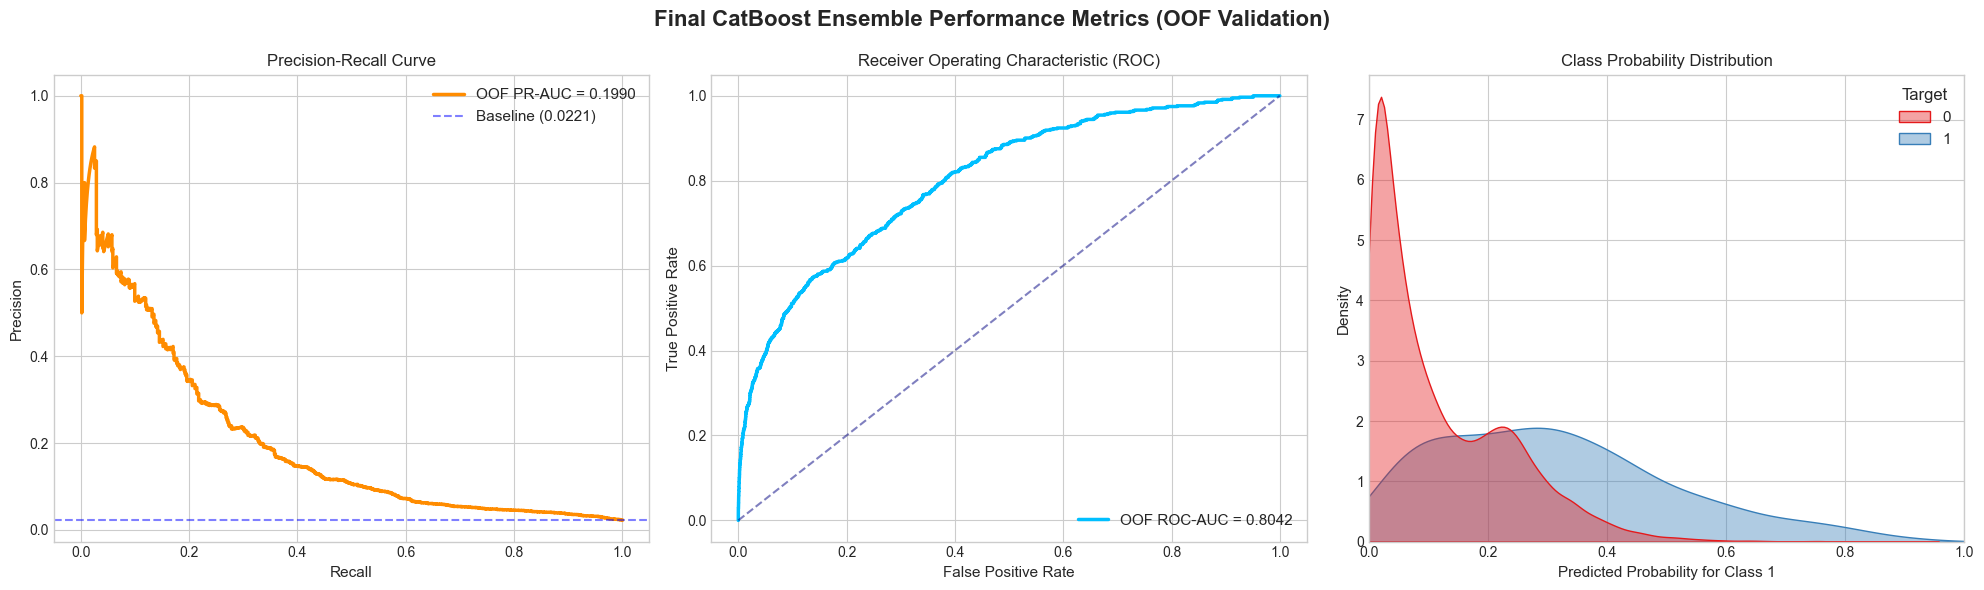

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# ==============================================================================
# 1. PARAMETER RESOLUTION (IN-MEMORY ONLY)
# ==============================================================================
DEFAULT_BEST_PARAMS = {
    "depth": 6,
    "learning_rate": 0.018669,
    "l2_leaf_reg": 11.6927,
    "random_strength": 0.6015,
    "min_data_in_leaf": 34,
    "max_ctr_complexity": 2,
    "one_hot_max_size": 7,
    "model_size_reg": 4.9675,
    "balance_strategy": "manual",
    "scale_pos_weight": 10.0958,
}

best_params = None

if "study" in locals() or "study" in globals():
    print("[INFO] Active Optuna study detected in memory. Extracting trial parameters.")
    best_params = study.best_params.copy()
else:
    print("[INFO] Optuna study object not found. Reverting to default standard parameters.")
    best_params = DEFAULT_BEST_PARAMS.copy()

if "loss_strategy" in best_params:
    loss_strat = best_params.pop("loss_strategy")
    if loss_strat == "focal_loss":
        best_params["loss_function"] = "FocalLoss:alpha=0.25;gamma=2.0"
    elif loss_strat in ["logloss_auto", "logloss_manual"]:
        best_params["loss_function"] = "Logloss"
elif "balance_strategy" in best_params:
    best_params.pop("balance_strategy")
    best_params["loss_function"] = "Logloss"

if (
    "scale_pos_weight" in best_params or "auto_class_weights" in best_params
) and "loss_function" not in best_params:
    best_params["loss_function"] = "Logloss"

final_fixed_params = dict(
    iterations=2500,
    eval_metric="PRAUC",
    verbose=100,
    allow_writing_files=False,
    random_seed=RANDOM_STATE,
    thread_count=-1,
)
final_cb_params = {**final_fixed_params, **best_params}

print("\n[INFO] Resolved Hyperparameters for Final Training Pipeline:")
for k, v in final_cb_params.items():
    print(f"  {k}: {v}")


# ==============================================================================
# 2. ENSEMBLE TRAINING & OUT-OF-FOLD (OOF) ESTIMATION
# ==============================================================================
final_models = []
oof_preds = np.zeros(len(X_all))

print("\n[INFO] Initializing final ensemble training via Stratified K-Fold...")

for fold_idx, (train_idx, val_idx) in enumerate(splits):
    print(f"\n--- Training Fold {fold_idx} ---")
    train_pool, val_pool, y_va = precomputed_pools[fold_idx]

    fold_params = final_cb_params.copy()
    fold_params["random_seed"] = RANDOM_STATE + fold_idx

    model = CatBoostClassifier(**fold_params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=200,
        use_best_model=True,
    )

    val_prob = model.predict_proba(val_pool)[:, 1]
    oof_preds[val_idx] = val_prob

    final_models.append(model)
    print(f"[SUCCESS] Fold {fold_idx} training completed. PR-AUC: {average_precision_score(y_va, val_prob):.4f}")


# ==============================================================================
# 3. SAFELY CHECK AND EXECUTE TEST SET INFERENCE
# ==============================================================================
# Check workspace dynamically for test variables to prevent hard NameErrors
raw_test_variable_name = None
for name in ["X_test", "test_df", "df_test", "X_test_raw"]:
    if name in locals() or name in globals():
        raw_test_variable_name = name
        break

if raw_test_variable_name:
    print(f"\n[INFO] Test data detected via variable '{raw_test_variable_name}'. Initializing pipeline transformations...")
    raw_test_data = globals()[raw_test_variable_name] if raw_test_variable_name in globals() else locals()[raw_test_variable_name]
    
    # Replicate structural tree preprocessing mappings
    X_test_cb, _ = prepare_for_trees(raw_test_data, raw_test_data, final_cat)
    X_test_cb.columns = sanitize_names(X_test_cb.columns.tolist())
    
    test_pool = Pool(X_test_cb, cat_features=cat_feature_indices)
    test_preds = np.zeros(len(X_test_cb))
    
    # Blend predictions across the fold ensemble
    for model in final_models:
        test_preds += model.predict_proba(test_pool)[:, 1]
    test_preds /= len(final_models)
    print("[SUCCESS] Ensemble test inference successfully compiled into `test_preds` array.")
else:
    print("\n[WARNING] Raw test dataframe ('X_test') not found in local or global scope. Skipping inference step.")


# ==============================================================================
# 4. PERFORMANCE EVALUATION & VISUALIZATION
# ==============================================================================
print("\n[INFO] Generating validation performance charts...")
oof_pr_auc = average_precision_score(y_all, oof_preds)
oof_roc_auc = roc_auc_score(y_all, oof_preds)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_all, oof_preds)
axes[0].plot(recall, precision, color="darkorange", lw=2.5, label=f"OOF PR-AUC = {oof_pr_auc:.4f}")
axes[0].axhline(y=np.mean(y_all), color="blue", linestyle="--", alpha=0.5, label=f"Baseline ({np.mean(y_all):.4f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="upper right")

# Plot 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_all, oof_preds)
axes[1].plot(fpr, tpr, color="deepskyblue", lw=2.5, label=f"OOF ROC-AUC = {oof_roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].legend(loc="lower right")

# Plot 3: Probability Distribution Density Plot
df_probs = pd.DataFrame({"Probability": oof_preds, "Target": y_all})
sns.kdeplot(data=df_probs, x="Probability", hue="Target", fill=True, common_norm=False, palette="Set1", alpha=0.4, ax=axes[2])
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Predicted Probability for Class 1")
axes[2].set_ylabel("Density")
axes[2].set_title("Class Probability Distribution")

plt.suptitle("Final CatBoost Ensemble Performance Metrics (OOF Validation)", fontsize=16, weight="bold")
plt.tight_layout()

plt.savefig("final_model_performance.png", dpi=300, bbox_inches="tight")
print("[INFO] Charts successfully compiled and exported to 'final_model_performance.png'")

print("\n" + "=" * 70)
print("📈 FINAL OUT-OF-FOLD PERFORMANCE SUMMARY:")
print("=" * 70)
print(f"   Overall OOF PR-AUC  : {oof_pr_auc:.5f}")
print(f"   Overall OOF ROC-AUC : {oof_roc_auc:.5f}")
print("=" * 70)


[INFO] Generating validation performance charts...
[INFO] Charts successfully compiled and exported to 'final_model_performance.png'

📈 FINAL CROSS-VALIDATION PERFORMANCE SUMMARY:
   Mean CV PR-AUC  : 0.23655 ± 0.07998
   Mean CV ROC-AUC : 0.86648


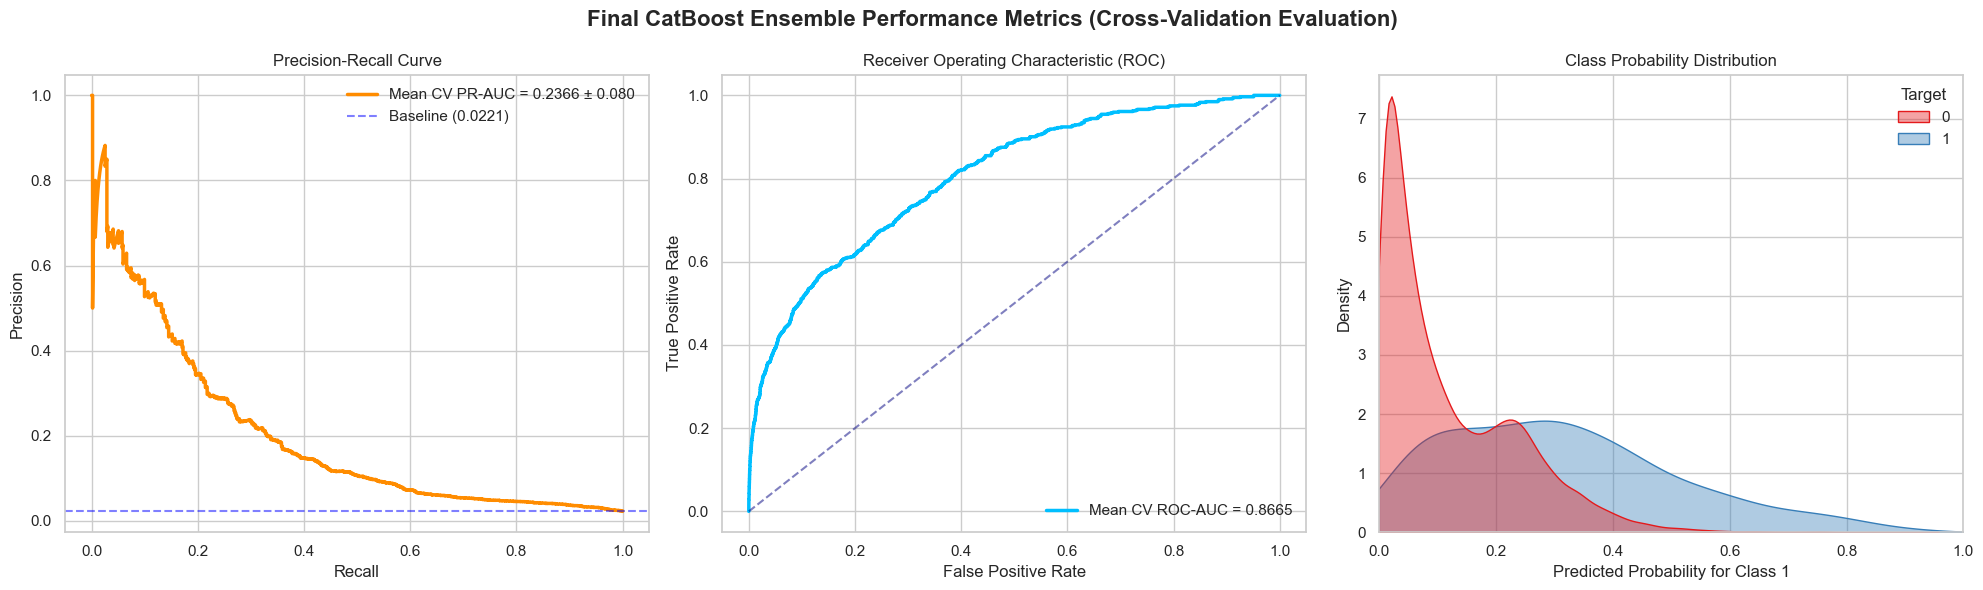

In [27]:
# ==============================================================================
# 4. PERFORMANCE EVALUATION & VISUALIZATION (FIXED METRIC METRIC LOGIC)
# ==============================================================================
print("\n[INFO] Generating validation performance charts...")

# Compute true cross-validation metrics across individual folds
fold_pr_aucs = []
fold_roc_aucs = []

for fold_idx, (_, val_idx) in enumerate(splits):
    f_target = y_all[val_idx]
    f_pred = oof_preds[val_idx]
    
    fold_pr_aucs.append(average_precision_score(f_target, f_pred))
    fold_roc_aucs.append(roc_auc_score(f_target, f_pred))

mean_cv_pr_auc = np.mean(fold_pr_aucs)
std_cv_pr_auc = np.std(fold_pr_aucs)
mean_cv_roc_auc = np.mean(fold_roc_aucs)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Plot 1: Precision-Recall Curve (Using Global Pooled Baseline reference)
precision, recall, _ = precision_recall_curve(y_all, oof_preds)
axes[0].plot(
    recall,
    precision,
    color="darkorange",
    lw=2.5,
    label=f"Mean CV PR-AUC = {mean_cv_pr_auc:.4f} ± {std_cv_pr_auc:.3f}",
)
axes[0].axhline(
    y=np.mean(y_all),
    color="blue",
    linestyle="--",
    alpha=0.5,
    label=f"Baseline ({np.mean(y_all):.4f})",
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend(loc="upper right")

# Plot 2: ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_all, oof_preds)
axes[1].plot(
    fpr,
    tpr,
    color="deepskyblue",
    lw=2.5,
    label=f"Mean CV ROC-AUC = {mean_cv_roc_auc:.4f}",
)
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--", alpha=0.5)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].legend(loc="lower right")

# Plot 3: Probability Distribution Density Plot
df_probs = pd.DataFrame({"Probability": oof_preds, "Target": y_all})
sns.kdeplot(
    data=df_probs,
    x="Probability",
    hue="Target",
    fill=True,
    common_norm=False,
    palette="Set1",
    alpha=0.4,
    ax=axes[2],
)
axes[2].set_xlim(0, 1)
axes[2].set_xlabel("Predicted Probability for Class 1")
axes[2].set_ylabel("Density")
axes[2].set_title("Class Probability Distribution")

plt.suptitle(
    "Final CatBoost Ensemble Performance Metrics (Cross-Validation Evaluation)",
    fontsize=16,
    weight="bold",
)
plt.tight_layout()

plt.savefig("final_model_performance.png", dpi=300, bbox_inches="tight")
print("[INFO] Charts successfully compiled and exported to 'final_model_performance.png'")

print("\n" + "=" * 70)
print("📈 FINAL CROSS-VALIDATION PERFORMANCE SUMMARY:")
print("=" * 70)
print(f"   Mean CV PR-AUC  : {mean_cv_pr_auc:.5f} ± {std_cv_pr_auc:.5f}")
print(f"   Mean CV ROC-AUC : {mean_cv_roc_auc:.5f}")
print("=" * 70)